In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [8]:
# define state

class BMIState(TypedDict):

    weight_kg : float
    height_m : float
    bmi : float
    category : str

In [9]:
# define function

def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight / (height**2)

    state['bmi'] = round(bmi,2)

    return state



def category_cal(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi <= 24.9:
        category = "Normal weight"
    elif 25.0 <= bmi <= 29.9:
        category = "Overweight"
    else:
        category = "Obese"

    state['category'] = category

    return state

In [10]:
# define your graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("category_cal",category_cal)

# add edges to your graph
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi","category_cal")
graph.add_edge("category_cal", END)

# compile the graph
workflow = graph.compile()

In [11]:
# execute the graph
initial_state = {"weight_kg":80, "height_m":1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


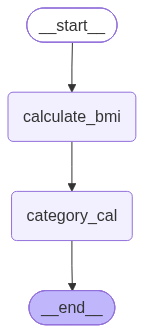

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())